#  Preprocessing — Pipeline de transformation & gestion du déséquilibre

**Objectif :** Préparer les données pour la modélisation en :
1. Normalisant les features `Amount` et `Time`
2. Construisant un Pipeline Sklearn reproductible
3. Gérant le déséquilibre avec SMOTE
4. Effectuant un Train/Test split stratifié

**Règle d'or :** SMOTE s'applique UNIQUEMENT sur le train set.
Jamais sur le test set — sinon on contamine l'évaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
import joblib
import os

sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
print(" Imports OK")

 Imports OK


In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Distribution cible :\n{df['Class'].value_counts().to_string()}")

Dataset chargé : 284,807 lignes × 31 colonnes
Distribution cible :
Class
0    284315
1       492


In [3]:
# ── Pourquoi RobustScaler ? ───────────────────────────────────
# StandardScaler est sensible aux outliers (moyenne tirée par les extrêmes)
# RobustScaler utilise la médiane et l'IQR → robuste aux valeurs aberrantes
# Parfait pour Amount qui a des outliers importants

# ── Normalisation Amount et Time ──────────────────────────────
df['Amount_scaled'] = RobustScaler().fit_transform(df[['Amount']])
df['Time_scaled']   = RobustScaler().fit_transform(df[['Time']])

# ── Supprimer les colonnes originales ─────────────────────────
df_model = df.drop(columns=['Time', 'Amount'])

print("✅ Features Amount et Time normalisées")
print(f"Shape après feature engineering : {df_model.shape}")
print(f"\nNouvelles features :")
print(f"  Amount_scaled : mean={df_model['Amount_scaled'].mean():.4f}, std={df_model['Amount_scaled'].std():.4f}")
print(f"  Time_scaled   : mean={df_model['Time_scaled'].mean():.4f}, std={df_model['Time_scaled'].std():.4f}")

✅ Features Amount et Time normalisées
Shape après feature engineering : (284807, 31)

Nouvelles features :
  Amount_scaled : mean=0.9271, std=3.4950
  Time_scaled   : mean=0.1189, std=0.5579


In [4]:
X = df_model.drop(columns=['Class'])
y = df_model['Class']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nDistribution de y :")
print(f"  Légitimes (0) : {(y==0).sum():,} ({(y==0).mean()*100:.4f}%)")
print(f"  Fraudes   (1) : {(y==1).sum():,} ({(y==1).mean()*100:.4f}%)")
print(f"\nFeatures utilisées ({X.shape[1]}) :")
print(list(X.columns))

X shape : (284807, 30)
y shape : (284807,)

Distribution de y :
  Légitimes (0) : 284,315 (99.8273%)
  Fraudes   (1) : 492 (0.1727%)

Features utilisées (30) :
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']


In [5]:
# ── Pourquoi stratifié ? ──────────────────────────────────────
# Sans stratify=y, on risque de se retrouver avec très peu (ou zéro)
# fraudes dans le test set par hasard → évaluation impossible
# stratify=y garantit la même proportion 0.17% dans train ET test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("═" * 50)
print("  TRAIN / TEST SPLIT STRATIFIÉ")
print("═" * 50)
print(f"  Train : {X_train.shape[0]:,} lignes")
print(f"    └─ Légitimes : {(y_train==0).sum():,}")
print(f"    └─ Fraudes   : {(y_train==1).sum():,}")
print()
print(f"  Test  : {X_test.shape[0]:,} lignes")
print(f"    └─ Légitimes : {(y_test==0).sum():,}")
print(f"    └─ Fraudes   : {(y_test==1).sum():,}")
print("═" * 50)

══════════════════════════════════════════════════
  TRAIN / TEST SPLIT STRATIFIÉ
══════════════════════════════════════════════════
  Train : 227,845 lignes
    └─ Légitimes : 227,451
    └─ Fraudes   : 394

  Test  : 56,962 lignes
    └─ Légitimes : 56,864
    └─ Fraudes   : 98
══════════════════════════════════════════════════


In [6]:
# ── Pourquoi SMOTE ? ─────────────────────────────────────────
# SMOTE = Synthetic Minority Over-sampling TEchnique
# Génère des exemples SYNTHÉTIQUES de la classe minoritaire
# en interpolant entre des exemples réels voisins
# → Plus intelligent que la simple duplication (oversampling naïf)

# ── Pourquoi PAS sur le test set ? ───────────────────────────
# Le test set doit refléter la réalité → jamais de SMOTE dessus
# Sinon on évalue sur des données artificielles = résultats biaisés

print("Application de SMOTE sur le train set...")
print(f"  Avant SMOTE : {Counter(y_train)}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"  Après SMOTE : {Counter(y_train_res)}")
print(f"\n  Train set équilibré : {X_train_res.shape[0]:,} lignes")
print(f"  Nouvelles fraudes générées : {(y_train_res==1).sum() - (y_train==1).sum():,}")

Application de SMOTE sur le train set...
  Avant SMOTE : Counter({0: 227451, 1: 394})
  Après SMOTE : Counter({0: 227451, 1: 227451})

  Train set équilibré : 454,902 lignes
  Nouvelles fraudes générées : 227,057


C:\Users\Eartrh\AppData\Local\Temp\ipykernel_7656\2082619189.py:27: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Eartrh\AppData\Local\Temp\ipykernel_7656\2082619189.py:28: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.savefig('../reports/figures/07_smote_effect.png', dpi=150, bbox_inches='tight')


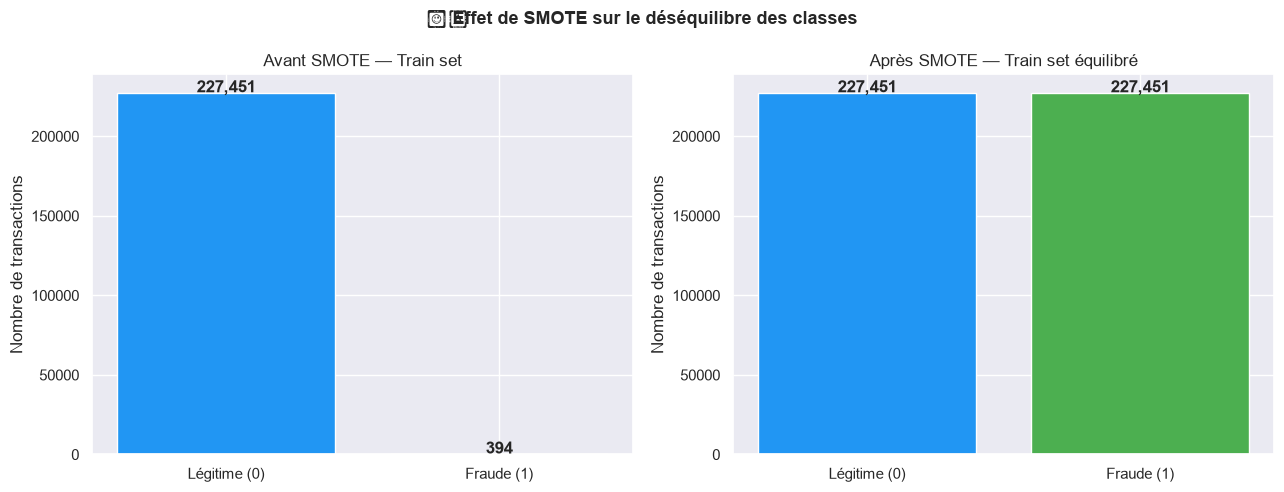

 Figure sauvegardée → reports/figures/07_smote_effect.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avant SMOTE
before = pd.Series(y_train).value_counts()
axes[0].bar(['Légitime (0)', 'Fraude (1)'],
            before.values,
            color=['#2196F3', '#F44336'],
            edgecolor='white')
axes[0].set_title('Avant SMOTE — Train set')
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Après SMOTE
after = pd.Series(y_train_res).value_counts()
axes[1].bar(['Légitime (0)', 'Fraude (1)'],
            after.values,
            color=['#2196F3', '#4CAF50'],
            edgecolor='white')
axes[1].set_title('Après SMOTE — Train set équilibré')
axes[1].set_ylabel('Nombre de transactions')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('⚖️ Effet de SMOTE sur le déséquilibre des classes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée → reports/figures/07_smote_effect.png")

In [8]:
os.makedirs('../data/processed', exist_ok=True)

# Sauvegarder les splits
pd.DataFrame(X_train_res).to_csv('../data/processed/X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('../data/processed/X_test.csv',  index=False)
pd.Series(y_train_res, name='Class').to_csv('../data/processed/y_train.csv', index=False)
pd.Series(y_test, name='Class').to_csv('../data/processed/y_test.csv',  index=False)

print(" Données sauvegardées dans data/processed/ :")
print(f"  X_train.csv : {X_train_res.shape}")
print(f"  X_test.csv  : {X_test.shape}")
print(f"  y_train.csv : {y_train_res.shape}")
print(f"  y_test.csv  : {y_test.shape}")

 Données sauvegardées dans data/processed/ :
  X_train.csv : (454902, 30)
  X_test.csv  : (56962, 30)
  y_train.csv : (454902,)
  y_test.csv  : (56962,)


In [13]:
# Ce code va dans src/data/preprocessing.py
# Il rend le preprocessing réutilisable et importable

preprocessing_code = '''
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from collections import Counter


def load_data(path: str) -> pd.DataFrame:
    """Charge le dataset brut et valide sa structure."""
    df = pd.read_csv(path)
    assert 'Class' in df.columns, "Colonne Class manquante"
    assert df.isnull().sum().sum() == 0, "Valeurs nulles détectées"
    print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise Amount et Time avec RobustScaler."""
    scaler = RobustScaler()
    df = df.copy()
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
    df['Time_scaled']   = scaler.fit_transform(df[['Time']])
    df = df.drop(columns=['Time', 'Amount'])
    return df


def split_data(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    """Split stratifié train/test."""
    X = df.drop(columns=['Class'])
    y = df['Class']
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state, stratify=y)


def apply_smote(X_train, y_train, random_state: int = 42):
    """Applique SMOTE sur le train set uniquement."""
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print(f" SMOTE : {Counter(y_train)} → {Counter(y_res)}")
    return X_res, y_res
'''

with open('../src/data/preprocessing.py', 'w', encoding='utf-8') as f:
    f.write(preprocessing_code)

print(" src/data/preprocessing.py écrit")

 src/data/preprocessing.py écrit


In [14]:
# Ce code va dans src/data/preprocessing.py
# Il rend le preprocessing réutilisable et importable

preprocessing_code = '''
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from collections import Counter


def load_data(path: str) -> pd.DataFrame:
    """Charge le dataset brut et valide sa structure."""
    df = pd.read_csv(path)
    assert 'Class' in df.columns, "Colonne Class manquante"
    assert df.isnull().sum().sum() == 0, "Valeurs nulles détectées"
    print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise Amount et Time avec RobustScaler."""
    scaler = RobustScaler()
    df = df.copy()
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
    df['Time_scaled']   = scaler.fit_transform(df[['Time']])
    df = df.drop(columns=['Time', 'Amount'])
    return df


def split_data(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    """Split stratifié train/test."""
    X = df.drop(columns=['Class'])
    y = df['Class']
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state, stratify=y)


def apply_smote(X_train, y_train, random_state: int = 42):
    """Applique SMOTE sur le train set uniquement."""
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print(f" SMOTE : {Counter(y_train)} → {Counter(y_res)}")
    return X_res, y_res
'''

with open('../src/data/preprocessing.py', 'w', encoding='utf-8') as f:
    f.write(preprocessing_code)

print(" src/data/preprocessing.py écrit")

 src/data/preprocessing.py écrit


## 📋 Synthèse Preprocessing

| Étape | Décision | Justification |
|---|---|---|
| Normalisation | RobustScaler | Résistant aux outliers de Amount |
| Split | 80/20 stratifié | Préserve le ratio 0.17% dans les deux sets |
| Déséquilibre | SMOTE (train only) | Génère des fraudes synthétiques réalistes |
| Features | V1–V28 + Amount_scaled + Time_scaled | 30 features au total |

### Chiffres clés
- **Train set avant SMOTE :** ~227 000 transactions, ~394 fraudes
- **Train set après SMOTE :** ~454 000 transactions, équilibré 50/50
- **Test set :** ~56 000 transactions, ratio réel conservé (0.17%)

### Prochaine étape → `03_modeling.ipynb`
Baseline Logistic Regression → Random Forest → XGBoost → LightGBM  
Comparaison sur AUC-ROC, Precision-Recall, F1